Generating hypergraph (n=1500, kappa=6.0) ...
m (num edges) = 3000

--- combo init0.20_eta0.60: init=0.2, eta=0.6 ---
 beta=0.160 -> rho=0.000000  ⟨Θ⟩=1.0000  iters=530  conv=True
 beta=0.161 -> rho=0.000000  ⟨Θ⟩=1.0000  iters=531  conv=True
 beta=0.162 -> rho=0.000000  ⟨Θ⟩=1.0000  iters=532  conv=True
 beta=0.163 -> rho=0.000000  ⟨Θ⟩=1.0000  iters=533  conv=True
 beta=0.164 -> rho=0.000000  ⟨Θ⟩=1.0000  iters=534  conv=True
 beta=0.165 -> rho=0.000000  ⟨Θ⟩=1.0000  iters=535  conv=True
 beta=0.166 -> rho=0.000000  ⟨Θ⟩=1.0000  iters=536  conv=True
 beta=0.167 -> rho=0.000000  ⟨Θ⟩=1.0000  iters=538  conv=True
 beta=0.168 -> rho=0.000000  ⟨Θ⟩=1.0000  iters=541  conv=True
 beta=0.169 -> rho=0.000000  ⟨Θ⟩=1.0000  iters=546  conv=True
 beta=0.170 -> rho=0.000000  ⟨Θ⟩=1.0000  iters=556  conv=True
 beta=0.171 -> rho=0.343414  ⟨Θ⟩=0.4073  iters=1000  conv=False
 beta=0.172 -> rho=0.344528  ⟨Θ⟩=0.4047  iters=1000  conv=False
 beta=0.173 -> rho=0.346099  ⟨Θ⟩=0.4018  iters=1000  conv=False
 beta=0.

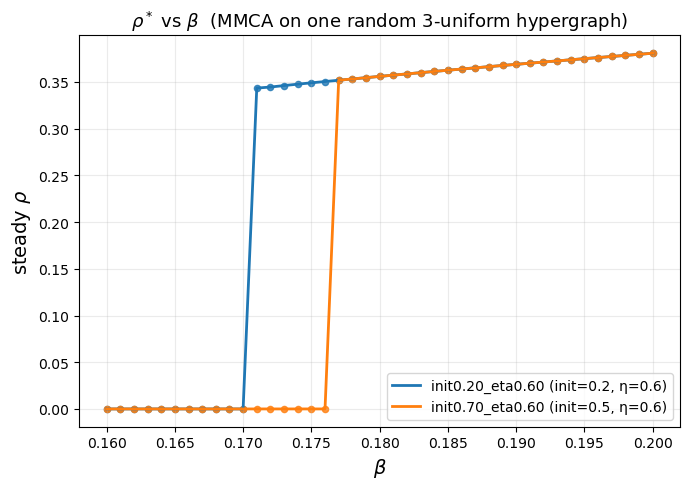

Plot saved to mmca_rho_vs_beta_out\rho_vs_beta_mmca.png
Saved combined summary: mmca_rho_vs_beta_out\mmca_rho_beta_summary_combined.csv


In [3]:
#!/usr/bin/env python3
# mmca_rho_vs_beta_param_scan.py
"""
探究不同初始感染密度和不同eta对稳态感染密度的影响
MMCA sweep on one random 3-uniform hypergraph:
 - Sweep beta in [beta_min, beta_max]
 - For each (init_frac, eta) pair compute steady rho (MMCA)
 - Save CSVs and plot rho* vs beta (three curves on same figure)

Usage: run this file directly (parameters at bottom).
"""
import os
import time
import math
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -------------------- Hypergraph generator H(n,m,3) --------------------
def generate_hypergraph_H_n_m_3(n, kappa, seed=None, batch_size=3000):
    """生成随机 3-uniform 超图 H(n,m,3)，返回 ndarray (m,3)，每行已排序。"""
    if seed is not None:
        rng = np.random.RandomState(seed)
    else:
        rng = np.random
    d = 3
    m = int(round(n * kappa / d))
    max_possible = math.comb(n, d)
    if m > max_possible:
        raise ValueError("m > C(n,3)")
    nodes = np.arange(n)
    edges_set = set()
    # 批量候选采样，避免大量 python 循环开销
    while len(edges_set) < m:
        tris = rng.choice(nodes, size=(batch_size, d), replace=True)
        for i in range(tris.shape[0]):
            row = tris[i]
            if len(np.unique(row)) < d:
                # 若有重复则强制重采样该行
                row = rng.choice(nodes, size=(d,), replace=False)
            tris[i] = np.sort(row)
        for row in tris:
            if len(edges_set) >= m:
                break
            edges_set.add(tuple(row.tolist()))
    hyperedges = np.array(list(edges_set), dtype=int)
    hyperedges.sort(axis=1)
    return hyperedges

# -------------------- MMCA implementation on one hypergraph --------------------
class MMCA:
    def __init__(self, hyperedges, n):
        self.hyperedges = np.asarray(hyperedges, dtype=int)
        self.n = n
        self.m = self.hyperedges.shape[0]
        # endpoints for vector ops
        self.i = self.hyperedges[:,0].astype(int)
        self.j = self.hyperedges[:,1].astype(int)
        self.k = self.hyperedges[:,2].astype(int)
        # node incidence list: node -> list of (edge_idx, position)
        self.node_edge_pos = [[] for _ in range(n)]
        for ei in range(self.m):
            a,b,c = self.hyperedges[ei]
            self.node_edge_pos[a].append((ei,0))
            self.node_edge_pos[b].append((ei,1))
            self.node_edge_pos[c].append((ei,2))

    def run_to_converge(self, beta_d, mu, eta, gamma,
                        init_frac=0.01, Theta0=1.0,
                        tol=1e-8, max_iters=500):
        """
        从 p_i(0)=init_frac, Theta_e(0)=Theta0 运行 MMCA 到收敛。
        返回 (steady_rho, steady_Theta_mean, iters_taken, converged_bool)
        """
        p = np.full(self.n, float(init_frac), dtype=float)
        Theta = np.full(self.m, float(Theta0), dtype=float)

        for it in range(1, max_iters+1):
            # 1) 计算每条边在三种位置上的 other-product
            p_i = p[self.i]; p_j = p[self.j]; p_k = p[self.k]
            prod_pos0 = p_j * p_k
            prod_pos1 = p_i * p_k
            prod_pos2 = p_i * p_j

            # 2) 计算每个节点的 Q = ∏_{e∈E_i} (1 - Θ_e β ∏_{j∈e\{i}} p_j)
            Q = np.ones(self.n, dtype=float)
            # 用节点循环（清晰可靠）
            for node in range(self.n):
                pv = 1.0
                for (ei,pos) in self.node_edge_pos[node]:
                    if pos == 0:
                        oth = prod_pos0[ei]
                    elif pos == 1:
                        oth = prod_pos1[ei]
                    else:
                        oth = prod_pos2[ei]
                    pv *= (1.0 - Theta[ei] * beta_d * oth)
                Q[node] = pv

            # 3) MMCA 更新 p
            p_next = (1.0 - p) * (1.0 - Q) + (1.0 - mu) * p

            # 4) Theta 更新
            Phi = p_i * p_j * p_k
            Theta_next = Theta * (1.0 - eta * Phi) + gamma * (1.0 - Theta)
            Theta_next = np.clip(Theta_next, 0.0, 1.0)

            # 5) 收敛判据（p 和 Theta 都小于 tol）
            dp = np.max(np.abs(p_next - p))
            dTheta = np.max(np.abs(Theta_next - Theta))
            p = p_next
            Theta = Theta_next
            if dp < tol and dTheta < tol:
                return float(p.mean()), float(Theta.mean()), it, True

        # 未收敛到 tol，但返回当前状态
        return float(p.mean()), float(Theta.mean()), max_iters, False

# -------------------- 运行参数（在文件末尾可修改） --------------------
# （默认值可直接在脚本底部修改）
# -------------------- 主体工作函数 --------------------
def scan_rho_vs_beta_on_one_graph(n, kappa, beta_list, combos,
                                  mu=0.1, gamma=0.02,
                                  tol=1e-8, max_iters=500, seed=None,
                                  out_dir="mmca_rho_vs_beta_out"):
    """
    combos: list of tuples (init_frac, eta, label)
    为每个 combo 在相同 hypergraph 上对 beta_list 逐点运行 MMCA 并保存 CSV 与绘图数据
    返回： dict label -> (beta_list, rho_list, theta_list, iters_list, converged_list)
    """
    os.makedirs(out_dir, exist_ok=True)

    # 生成单张超图（不同 combo 共用同一拓扑，便于比较）
    hyper_seed = seed if seed is not None else 0
    print(f"Generating hypergraph (n={n}, kappa={kappa}) ...")
    hyperedges = generate_hypergraph_H_n_m_3(n=n, kappa=kappa, seed=hyper_seed)
    print("m (num edges) =", hyperedges.shape[0])

    results = {}
    # 为每个 combo 做扫描
    for (init_frac, eta, label) in combos:
        print(f"\n--- combo {label}: init={init_frac}, eta={eta} ---")
        rho_list = []
        theta_list = []
        iters_list = []
        conv_list = []
        mmodel = MMCA(hyperedges, n)

        for beta in beta_list:
            rho_final, theta_mean, iters, conv = mmodel.run_to_converge(
                beta_d=beta, mu=mu, eta=eta, gamma=gamma,
                init_frac=init_frac, Theta0=1.0, tol=tol, max_iters=max_iters
            )
            rho_list.append(rho_final)
            theta_list.append(theta_mean)
            iters_list.append(iters)
            conv_list.append(conv)
            print(f" beta={beta:.3f} -> rho={rho_final:.6f}  ⟨Θ⟩={theta_mean:.4f}  iters={iters}  conv={conv}")

        # 保存为 CSV（每行对应一个 beta）
        df = pd.DataFrame({
            "beta": beta_list,
            "rho": rho_list,
            "theta_mean": theta_list,
            "iters": iters_list,
            "converged": conv_list
        })
        fn = os.path.join(out_dir, f"mmca_rho_beta_{label}.csv")
        df.to_csv(fn, index=False, float_format="%.6f")
        print("Saved:", fn)

        results[label] = (np.array(beta_list), np.array(rho_list), np.array(theta_list), np.array(iters_list), np.array(conv_list))
    return results

# -------------------- 绘图函数 --------------------
def plot_rho_vs_beta(results, combos, out_dir="mmca_rho_vs_beta_out",
                     colors=None, linewidth=2.0):
    os.makedirs(out_dir, exist_ok=True)
    if colors is None:
        colors = ['#1f77b4', '#ff7f0e', '#2ca02c']  # 默认三色
    plt.figure(figsize=(7,5))
    for (init_frac, eta, label), color in zip(combos, colors):
        beta_list, rho_list, *_ = results[label]
        plt.plot(beta_list, rho_list, label=f"{label} (init={init_frac}, η={eta})", color=color, linewidth=linewidth)
        # 标注点
        plt.scatter(beta_list, rho_list, color=color, s=20, alpha=0.8)
    plt.xlabel(r"$\beta$", fontsize=14)
    plt.ylabel(r"steady $\rho$", fontsize=14)
    plt.title(r"$\rho^*$ vs $\beta$  (MMCA on one random 3-uniform hypergraph)", fontsize=13)
    plt.legend()
    plt.grid(alpha=0.25)
    plt.tight_layout()
    figfile = os.path.join(out_dir, "rho_vs_beta_mmca.png")
    plt.savefig(figfile, dpi=300)
    plt.show()
    print("Plot saved to", figfile)

# -------------------- Parameter block （执行时可直接改这里） --------------------
# 你要的三条曲线参数
COMBOS = [
    (0.20, 0.6, "init0.20_eta0.60"),
    # (0.20, 0.8, "init0.20_eta0.80"),
    (0.50, 0.6, "init0.50_eta0.60")
]

# beta 扫描区间（包括端点）
BETA_MIN = 0.16
BETA_MAX = 0.20
BETA_STEPS = 41  # => 步长 0.001
BETA_LIST = np.linspace(BETA_MIN, BETA_MAX, BETA_STEPS)

# 其他模型/运行参数
N = 1500
KAPPA = 6.0
MU = 0.1
GAMMA = 0.02
TOL = 1e-6
MAX_ITERS = 1000
SEED = 12345
OUT_DIR = "mmca_rho_vs_beta_out"

# -------------------- 运行（脚本直接运行时执行） --------------------
t0 = time.time()
results = scan_rho_vs_beta_on_one_graph(
    n=N, kappa=KAPPA, beta_list=BETA_LIST, combos=COMBOS,
    mu=MU, gamma=GAMMA, tol=TOL, max_iters=MAX_ITERS,
    seed=SEED, out_dir=OUT_DIR
)
print("All combos finished in {:.1f}s".format(time.time()-t0))

# 绘图
plot_rho_vs_beta(results, COMBOS, out_dir=OUT_DIR, colors=['#1f77b4', '#ff7f0e', '#d62728'])

# -------------------- 合并 summary CSV（便于后续绘图/比较） --------------------
# 合并三组为一个 summary 文件（每列一个 combo 的 rho）
summary_df = pd.DataFrame({"beta": BETA_LIST})
for (_init, _eta, label) in COMBOS:
    summary_df[f"rho_{label}"] = results[label][1]
summary_fn = os.path.join(OUT_DIR, "mmca_rho_beta_summary_combined.csv")
summary_df.to_csv(summary_fn, index=False, float_format="%.6f")
print("Saved combined summary:", summary_fn)
